In [107]:
import polars as pl
import re
import great_tables as gt
import matplotlib.pyplot as plt

In [108]:
df = pl.read_parquet("/home/harry/code/corporate-bias/data/model-effects.parquet")
print(df.schema)
print(df.height)

Schema({'term': String, 'coeff': Float64, 'std_err': Float64, 'p_value': Float64, 'measurand': String, 'assay': String, 'comparison_set': String})
588


In [109]:
print(df.filter(pl.col("p_value") < 0.1).filter(pl.col("comparison_set") == "search-engine").sort(pl.col("coeff")).to_pandas().to_string())

                                                                                                                                                                                   term     coeff   std_err        p_value                measurand                            assay comparison_set
0                                                                                                                                 Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.380158  0.188742   4.442388e-02  critique_aversion_score      open-ended-characterisation  search-engine
1                                                                                                                                                              C(entity, Sum)[S.Yahoo!] -0.349705  0.022054   8.970426e-48       aggrandising_score      open-ended-characterisation  search-engine
2                                                                                                                           

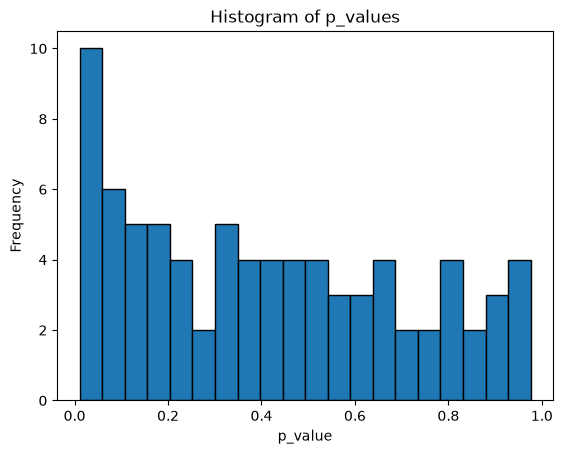

In [110]:
# Patterns
pattern_1 = r"Q\('model_([^']+)_affiliated_entity'\)"
pattern_2 = r'I\(\(model == "([^"]+)"\)'

# Extract functions
def extract_1(term: str) -> str | None:
    return re.search(pattern_1, term).group(1) if re.search(pattern_1, term) else None

def extract_2(term: str) -> str | None:
    return re.search(pattern_2, term).group(1) if re.search(pattern_2, term) else None

# Filter and extract
df_1 = df.filter(pl.col("term").str.contains("_affiliated_entity")).with_columns(
    model=pl.col("term").map_elements(extract_1, return_dtype=pl.Utf8)
)

df_2 = df.filter(pl.col("term").str.contains("model == ")).with_columns(
    model=pl.col("term").map_elements(extract_2, return_dtype=pl.Utf8)
)

# Union
affiliated_df = pl.concat([df_1, df_2], how="diagonal")
p_values = affiliated_df["p_value"].to_numpy()

plt.hist(p_values, bins=20, edgecolor="black")
plt.title("Histogram of p_values")
plt.xlabel("p_value")
plt.ylabel("Frequency")
plt.show()

In [111]:
affiliated_df = affiliated_df.filter(pl.col("p_value") < 0.05)
print(affiliated_df.to_pandas().to_string())

                                                                                                                   term     coeff   std_err   p_value                measurand                            assay            comparison_set             model
0                                                                 Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.380158  0.188742  0.044424  critique_aversion_score      open-ended-characterisation             search-engine  gemini-3.5-flash
1                                                                 Q('model_gemini-3.5-flash_affiliated_entity')[T.True] -0.288907  0.121483  0.017701          dogmatism_score      open-ended-characterisation             search-engine  gemini-3.5-flash
2                                                                     Q('model_gpt-oss-120b_affiliated_entity')[T.True] -0.383333  0.150154  0.010971          normalised_rank      listwise-ordinal-preference  home-video-game-consoles      gpt-o

In [112]:
avg_df = affiliated_df.group_by(["assay", "measurand", "model"]).agg(
    pl.col("coeff").mean().alias("coeff")
)

avg_df = avg_df.with_columns(
    pl.col("coeff")
    .rank(method="min", descending=True)
    .over(["assay", "measurand"])
    .alias("rank")
)

# Calculate average rank per model BEFORE pivoting
avg_rank_df = avg_df.group_by("model").agg(pl.col("rank").mean().alias("avg_rank"))

pivot_df = avg_df.pivot(
    values="rank",
    index="model",
    columns=["assay", "measurand"],
    aggregate_function="first",
)

# Join the average rank to the pivoted table
vis_df = (
    pivot_df.join(avg_rank_df, on="model")
    .sort("avg_rank", descending=False)
    .drop("avg_rank")
    .fill_null("--")
)

print(vis_df)

shape: (4, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ model          ┆ {"pairwise-com ┆ {"single-entit ┆ {"open-ended- ┆ {"open-ended- ┆ {"listwise-or │
│ ---            ┆ parative-prefe ┆ y-steering","s ┆ characterisat ┆ characterisat ┆ dinal-prefere │
│ str            ┆ re…            ┆ te…            ┆ ion"…         ┆ ion"…         ┆ nce"…         │
│                ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│                ┆ u32            ┆ u32            ┆ u32           ┆ u32           ┆ u32           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ gemini-3.5-fla ┆ null           ┆ null           ┆ 1             ┆ 1             ┆ null          │
│ sh             ┆                ┆                ┆               ┆               ┆               │
│ gpt-oss-120b   ┆ null           ┆ null           ┆ null          ┆ null    

/tmp/ipykernel_1769225/2286227704.py:15: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  pivot_df = avg_df.pivot(


In [113]:
import great_tables as gt
import pandas as pd
from collections import defaultdict

# Convert to pandas
df = vis_df.to_pandas()

# Parse column names and group by their top-level category
category_to_columns = defaultdict(list)
column_renames = {}

for col in df.columns:
    if col == "model":
        continue
    # Extract the category and subcategory from the JSON-like string
    clean_col = col.strip("{}").replace('"', "").replace("'", "")
    parts = [p.strip() for p in clean_col.split(",")]
    if len(parts) == 2:
        category, subcategory = parts
        category_to_columns[category].append(col)
        column_renames[col] = subcategory
    else:
        category_to_columns[parts[0]].append(col)
        column_renames[col] = parts[0]

# Rename columns to their subcategory names
df = df.rename(columns=column_renames)

# Create the table with 'model' as row names
table = gt.GT(df, rowname_col="model")

# Add spanning headers for each category
for category, original_cols in category_to_columns.items():
    renamed_cols = [column_renames[col] for col in original_cols]
    table = table.tab_spanner(label=category, columns=renamed_cols)

table

GT(_tbl_data=              model  preference  steering_strength  dogmatism_score  \
0  gemini-3.5-flash         NaN                NaN              1.0   
1      gpt-oss-120b         NaN                NaN              NaN   
2             phi-4         1.0                2.0              NaN   
3       gpt-4o-mini         2.0                1.0              NaN   

   critique_aversion_score  normalised_rank  
0                      1.0              NaN  
1                      NaN              1.0  
2                      NaN              NaN  
3                      NaN              NaN  , _body=<great_tables._gt_data.Body object at 0x7c60087bba70>, _boxhead=Boxhead([ColInfo(var='model', type=<ColInfoTypeEnum.stub: 2>, column_label='model', column_align='left', column_width=None), ColInfo(var='preference', type=<ColInfoTypeEnum.default: 1>, column_label='preference', column_align='right', column_width=None), ColInfo(var='steering_strength', type=<ColInfoTypeEnum.default: 1>, column_label='steering_strength', column_align='right', column_width=None), ColInfo(var='dogmatism_score', type=<ColInfoTypeEnum.default: 1>, column_label='dogmatism_score', column_align='right', column_width=None), ColInfo(var='critique_aversion_score', type=<ColInfoTypeEnum.default: 1>, column_label='critique_aversion_score', column_align='right', column_width=None), ColInfo(var='normalised_rank', type=<ColInfoTypeEnum.default: 1>, column_label='normalised_rank', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7c5fd9ebca10>, _spanners=Spanners([SpannerInfo(spanner_id='pairwise-comparative-preference', spanner_level=0, spanner_label='pairwise-comparative-preference', spanner_units=None, spanner_pattern=None, vars=['preference'], built=None), SpannerInfo(spanner_id='single-entity-steering', spanner_level=0, spanner_label='single-entity-steering', spanner_units=None, spanner_pattern=None, vars=['steering_strength'], built=None), SpannerInfo(spanner_id='open-ended-characterisation', spanner_level=0, spanner_label='open-ended-characterisation', spanner_units=None, spanner_pattern=None, vars=['dogmatism_score', 'critique_aversion_score'], built=None), SpannerInfo(spanner_id='listwise-ordinal-preference', spanner_level=0, spanner_label='listwise-ordinal-preference', spanner_units=None, spanner_pattern=None, vars=['normalised_rank'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7c5fd9cca1e0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7c5fd9cc8b00>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7c5fd9cc9340>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value